# MLP Classification with Unitary Evolution

This notebook contains an example of how we can use Hamiltonian Learning to replicate the effect of a Neural Network with the unitary evolution of a quantum state

## Imports

In [1]:
import numpy as np
import torch
from torchvision import transforms, datasets
import tensorkrowch as tk

import jax
import jax.numpy as jnp

import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import glob
import yaml
import matplotlib.pyplot as plt
import torchtt as tntt 

import sys
import os

sys.path.append('../src/')

from run_inference import run_inference
from plots import bar_plot_strings_comparison, plot_training_loss
from physics import paulis, kron_n, rk4_step, build_hamiltonian, schrodinger_rhs, evolve_state, time_evolution, physics_computation
from physics import OperatorClass, prepare_initial_state, initial_state_from_input
from NeuralNetworks import MPS_MLP

## Utils specific to this notebook

In [2]:
def load_config(config_path):
    '''Load configuration from YAML file'''
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def create_filename_core(config, N):
    chi_nn = config['bond_dimension_learning']
    kind = config['learning_mode']
    chi_mpo = config['MAX_MPO_CHI']
    mpo_on = config['MPO_ON']
    
    filename_core = f"L{N}_chi_nn-{chi_nn}_kind-{kind}_Chimpo-{chi_mpo}_MPO-{mpo_on}_class-7"

    return filename_core

def generate_bitstring_list(nqubits):
    '''Create list containing all possible bitstrings of the N-qubit chain'''
    bitstrings = []
    decimal_bitstrings = range(0, 2**nqubits)
    int_bitstrings = [bin(i)[2:].zfill(nqubits) for i in decimal_bitstrings]
    bitstrings =  [str(bit) for bit in int_bitstrings]

    return bitstrings

def min_power_of_2(n):
    if n <= 0:
        raise ValueError("Number must be positive")
    
    # If n is already a power of 2, return its exponent
    if (n & (n - 1)) == 0:
        return n.bit_length() - 1
    
    # Otherwise, return the bit length
    return n.bit_length()

def create_parameter_dict(params, OPS_LIST, L, CONFIG):
    """
    Create parameter dictionary from model output.
    FIXED: Better handling of parameter shapes.
    """
    predicted_params = {}
    
    # Ensure params is 1D
    if params.ndim > 1:
        params = params.squeeze()
    
    if params.ndim > 1:
        raise ValueError(f"params should be 1D after squeeze, got shape {params.shape}")
    
    idx = 0
    
    # 1. Hamiltonian parameters
    n_hamiltonian = len(OPS_LIST)
    predicted_params['theta'] = params[idx:idx + n_hamiltonian]
    idx += n_hamiltonian
    
    #Not used
    for field in ['x', 'y', 'z']:
        key = f'{field}_fields'
        if CONFIG.get(key, False):
            predicted_params[f'rot_{field}'] = params[idx:idx + L]
            idx += L
    
    # Verify we used all parameters
    if idx != params.shape[0]:
        raise ValueError(
            f"Parameter count mismatch. Used {idx} parameters, "
            f"but model output has {params.shape[0]}"
        )
    
    return predicted_params

## Training

In [3]:
def nll(psi, counts):
    #Propper format of data
    counts_torch = torch.from_numpy(counts)

    #Normalized probabilities
    probs = torch.abs(psi)**2
    probs = probs / probs.sum()

    #Avoid log(0) by clipping
    probs = torch.clip(probs, 1e-9, 1.0)

    #negative log likelihood (normalized)
    logp = torch.log(probs)
    ll = torch.sum(counts_torch * logp)
    loss_nll = -ll / torch.sum(counts_torch)

    return loss_nll

def train_model(model, n_epochs, input_data, psi0, OPS_LIST, L, CONFIG, 
                        t_grid_fine, learning_rate, counts_shots, print_every=50):
    """
    Improved training function with better convergence.
    """
    
    loss_history = []
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5
    )
    
    for epoch_i in range(n_epochs):

        optimizer.zero_grad()
        
        # Forward pass
        output_params = model(input_data)
        predicted_params = create_parameter_dict(output_params, OPS_LIST, L, CONFIG)
        
        # Physics computation
        psi_t = physics_computation(predicted_params, psi0, OPS_LIST, L, t_grid_fine)
        
        # Compute loss
        loss = nll(psi_t, counts_shots)
        
        # Add regularization to prevent parameter explosion
        if CONFIG.get('lambda_reg', 0) > 0:
            param_norm = sum(p.norm() for p in predicted_params.values() if isinstance(p, torch.Tensor))
            loss = loss + CONFIG['lambda_reg'] * param_norm
        
        # Backward pass
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Optimization step
        optimizer.step()
        
        # Record loss
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        # Learning rate scheduling
        scheduler.step(loss_val)
        
        # Print progress
        if epoch_i % print_every == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch_i:4d} | Loss: {loss_val:.6f} | LR: {current_lr:.2e}")
    
    return model, predicted_params, psi_t, loss_history

## Load and parse configuration file 

In [4]:
config_file = "../config/MLP_to_H_configuration.yaml"

# Load configuration
print(f"Loading config: {config_file}")
CONFIG = load_config(config_file)

# Main parameters
MLP_input_size = CONFIG['MLP_input_size']
MLP_output_size = CONFIG['MLP_output_size']
CHI = CONFIG['bond_dimension_learning']
learning_mode = CONFIG['learning_mode']
MLP_input_folder = CONFIG['MLP_input_folder']
MLP_input_file = CONFIG['MLP_input_file']
use_mpo = CONFIG['MPO_ON']
max_mpo_chi = CONFIG['MAX_MPO_CHI']

# Training parameters
n_epochs = CONFIG['N_epochs']
t_grid_fine = torch.arange(0.0, CONFIG["t_max"] + CONFIG["dt"]/2, CONFIG["dt"])
learning_rate = CONFIG['learning_rate']

# Set random seed
torch.manual_seed(CONFIG["seed_init"])
np.random.seed(CONFIG["seed_init"])

Loading config: ../config/MLP_to_H_configuration.yaml


## Load input

Load the input of the neural network and run the classical inference

In [5]:
#Load input
input_data = np.load(f"{MLP_input_file}")

#Run inference with MLP model
bitstring_probs, prediction = run_inference(input_data, MLP_input_folder, use_mpo, max_mpo_chi)

Predicted class: 7


## Initialize quantum state

Initialize state from given input and chose the learning mode

In [6]:
#Prepare initial state depending on the learning mode selected
if learning_mode == 'output_only':
    initial_state_kind = CONFIG['initial_state_kind']
    L = min_power_of_2(MLP_output_size)
    psi0 = prepare_initial_state(L, initial_state_kind)

    print(f"Learning only output of size {MLP_output_size} with {L} qubits")

elif learning_mode == 'output_from_input':
    L = min_power_of_2(MLP_input_size)
    psi0 = initial_state_from_input(L, input_data.flatten())

    print(f"Learning output from input of size {MLP_input_size} with {L} qubits")

dim = 2**L
#Input of training NN
mps_input_probs = torch.ones((1, L, 2))

#Add missing zeros to bistring probs
if len(bitstring_probs) < dim:
    # Create padded array with zeros
    padded_probs = np.zeros(dim)
    padded_probs[:len(bitstring_probs)] = bitstring_probs
    bitstring_probs = padded_probs

Learning output from input of size 784 with 10 qubits


## Initialize Hamiltonian and NN

In [7]:
# Initialize Hamiltonian operators
OPS_LIST = OperatorClass(L)
OPS_LIST.add_operators('ZZ')
OPS_LIST.add_operators('X')
OPS_LIST.add_operators('Z')
NUM_COEFFICIENTS = len(OPS_LIST)

# Calculate output dimension
NN_OUTPUT_DIM = NUM_COEFFICIENTS + sum(
    CONFIG.get(f'{axis}_fields', False) for axis in ['x', 'y', 'z']
) * L

#Create model to train
NNmodel = MPS_MLP(
    L=L, 
    chi=CHI, 
    num_params=NN_OUTPUT_DIM, 
    num_dims=[]
)

#Print run infor
print(f"\n{'='*60}")
print(f"Network Configuration:")
print(f"  Input dim: {L} qubits × 2 = {L*2}")
print(f"  Output dim: {NN_OUTPUT_DIM} parameters")
print(f"  - Hamiltonian: {NUM_COEFFICIENTS}")
print(f"  - Rotations: {NN_OUTPUT_DIM - NUM_COEFFICIENTS}")
print(f"{'='*60}\n")


ZZ terms added to the Hamiltonian
X terms added to the Hamiltonian
Z terms added to the Hamiltonian

Network Configuration:
  Input dim: 10 qubits × 2 = 20
  Output dim: 29 parameters
  - Hamiltonian: 29
  - Rotations: 0



## Train and save model

In [8]:
#Train model
NNmodel, final_params, psi_final, loss_history = train_model(
    NNmodel, 
    n_epochs, 
    mps_input_probs, 
    psi0, 
    OPS_LIST, 
    L,
    CONFIG, 
    t_grid_fine, 
    learning_rate, 
    bitstring_probs, 
    CONFIG['print_every']
)

# Save model
file_core = create_filename_core(CONFIG, L)
save_path = f"../saved_models/MPS-model_{file_core}.pt"
os.makedirs("../saved_models", exist_ok=True)

torch.save({
    'model_state_dict': NNmodel.state_dict(),
    'config': CONFIG,
    'loss_history': loss_history,
    'final_params': final_params
}, save_path)

print(f"\n✅ Model saved to: {save_path}")

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60 + "\n")

/Users/omichel/.pyenv/versions/retech_mpo/lib/python3.12/site-packages/tensorkrowch/components.py:1506: UserWarning: `tensor` is being cropped to fit the shape of node "stack_data_memory" at non-batch edges
  warnings.warn(f'`tensor` is being cropped to fit the shape of '
/Users/omichel/.pyenv/versions/retech_mpo/lib/python3.12/site-packages/tensorkrowch/components.py:1348: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return tensor[index]


Epoch    0 | Loss: 22.907448 | LR: 1.00e-02
Epoch    1 | Loss: 16.491944 | LR: 1.00e-02
Epoch    2 | Loss: 15.969965 | LR: 1.00e-02
Epoch    3 | Loss: 15.397925 | LR: 1.00e-02
Epoch    4 | Loss: 14.768067 | LR: 1.00e-02
Epoch    5 | Loss: 14.116007 | LR: 1.00e-02
Epoch    6 | Loss: 13.458032 | LR: 1.00e-02
Epoch    7 | Loss: 12.803206 | LR: 1.00e-02
Epoch    8 | Loss: 12.157620 | LR: 1.00e-02
Epoch    9 | Loss: 11.526258 | LR: 1.00e-02
Epoch   10 | Loss: 10.914000 | LR: 1.00e-02
Epoch   11 | Loss: 10.325893 | LR: 1.00e-02
Epoch   12 | Loss: 9.765775 | LR: 1.00e-02
Epoch   13 | Loss: 9.234807 | LR: 1.00e-02
Epoch   14 | Loss: 8.733544 | LR: 1.00e-02
Epoch   15 | Loss: 8.263668 | LR: 1.00e-02
Epoch   16 | Loss: 7.828134 | LR: 1.00e-02
Epoch   17 | Loss: 7.429892 | LR: 1.00e-02
Epoch   18 | Loss: 7.067257 | LR: 1.00e-02
Epoch   19 | Loss: 6.732215 | LR: 1.00e-02
Epoch   20 | Loss: 6.421300 | LR: 1.00e-02
Epoch   21 | Loss: 6.135085 | LR: 1.00e-02
Epoch   22 | Loss: 5.872382 | LR: 1.00e-02

## Diagnostics

In [9]:
# Compute final probabilities
probs_final = torch.abs(psi_final)**2
probs_np = probs_final.detach().numpy()
probs_np = probs_np / probs_np.sum()

# Normalize counts
normalized_counts = bitstring_probs / bitstring_probs.sum()


# Calculate divergence
total_divergence = np.sum(np.abs(normalized_counts - probs_np))
print(f"Total probability divergence: {total_divergence:.6f}")

# Calculate KL divergence
epsilon = 1e-10
kl_div = np.sum(
    normalized_counts * np.log((normalized_counts + epsilon) / (probs_np + epsilon))
)
print(f"KL divergence: {kl_div:.6f}")

# Print learned parameters
print("\nLearned parameters:")
for key, val in final_params.items():
    if isinstance(val, torch.Tensor):
        val_np = val.detach().numpy()
        print(f"  {key}: {val_np}")

Total probability divergence: 0.224764
KL divergence: 0.122818

Learned parameters:
  theta: [ 1.0199826e+00  1.4433721e+00  1.9167603e+00  1.2927754e+00
  1.5463824e+00  2.7127576e+00 -1.7772686e-01  4.5219150e+00
  1.1300896e+00 -1.2704179e-01 -2.9696985e-03 -1.0969460e+00
  2.0387781e+00 -4.5114383e-01  8.6627096e-02  6.7148119e-01
  1.4122207e+00  3.4040284e-01  1.6656289e+00  1.6169205e+00
 -1.6043314e-01  1.2529473e+00  2.1523006e+00  2.3946350e+00
  7.8052545e-01  1.4501959e+00 -1.0748937e+00 -2.7403393e+00
 -2.4063683e+00]


## Data saving

In [10]:
bitstrings = generate_bitstring_list(L)

#Save results

filename = f'../results/learned_hamiltonian_{file_core}'
np.savez(filename, np.array(final_params))

filename = f'../results/loss_history_{file_core}.npy'
np.save(filename, np.array(loss_history))

filename = f'../results/learned_distribution_{file_core}.npy'
data = np.array(list(zip(bitstrings, probs_np)))

## Plots

### Bitstring Histogram

TypeError: string indices must be integers, not 'str'

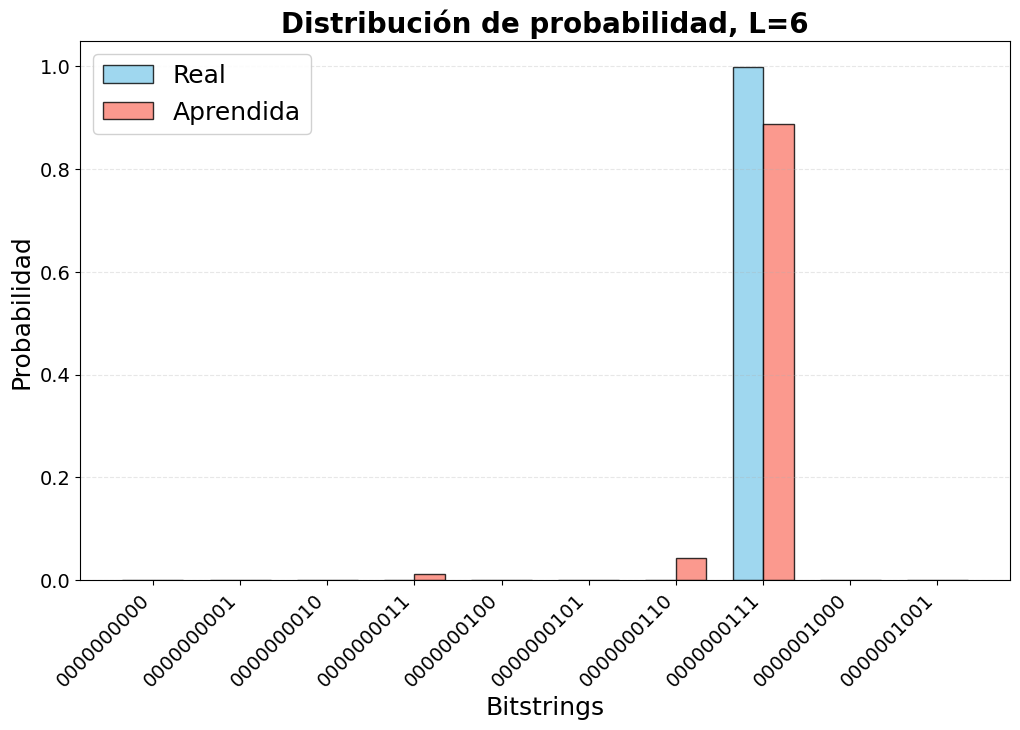

In [11]:
limit = int(MLP_output_size)
bar_plot_strings_comparison(bitstrings[0:limit], normalized_counts[0:limit], probs_np[0:limit], file_core)

### Loss

TypeError: string indices must be integers, not 'str'

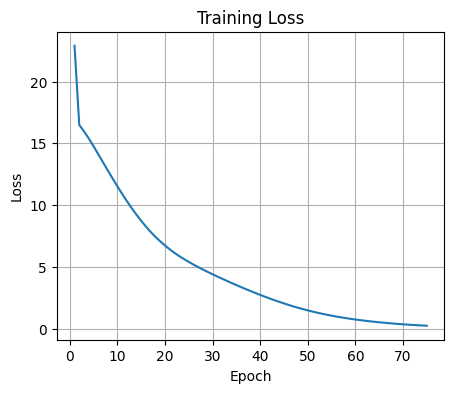

In [12]:
plot_training_loss(loss_history, file_core)